# Section 4.2. Calibration and simulation of the mean-reverting SDD model

## 0. Packages and variables

In [ ]:
import _paths  # noqa: F401
import pandas as pd

import plotting
from config import CONFIG, DT_DAILY, DT_MONTHLY
from paths import DATA
from plotting import use_paper_style as ups
from simulate import MeanRevertingSDDModel as SDDModel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
(width, height) = ups(usetex=True)

In [12]:
# Import config params
sim_cfg = CONFIG["simulation_config"]

IS_START_DATE, IS_END_DATE = sim_cfg["IS_dates"]
OOS_START_DATE, OOS_END_DATE = sim_cfg["OOS_dates"]
SEED = sim_cfg["SEED"]

IS_START_DATE, IS_END_DATE, OOS_START_DATE, OOS_END_DATE

('1977-01-01', '2004-12-31', '2005-01-01', '2024-12-31')

## 1. Data

In [13]:
signals = pd.read_csv(
    f"{DATA}/processed/signals_1977.csv", index_col=0, parse_dates=True
)

diversity = signals["diversity"]

diversity_monthly = diversity.resample("ME").last()
diversity_qv_monthly = diversity.diff().pow(2).resample("ME").sum() / DT_MONTHLY
dispersion_monthly = signals["dispersion"].resample("ME").sum() * DT_DAILY / DT_MONTHLY

IS_monthly_data = pd.DataFrame(
    {
        "diversity": diversity_monthly[IS_START_DATE:IS_END_DATE],
        "dispersion": dispersion_monthly[IS_START_DATE:IS_END_DATE],
        "diversity_qv": diversity_qv_monthly[IS_START_DATE:IS_END_DATE],
    }
)

OOS_monthly_data = pd.DataFrame(
    {
        "diversity": diversity_monthly[OOS_START_DATE:OOS_END_DATE],
        "dispersion": dispersion_monthly[OOS_START_DATE:OOS_END_DATE],
    }
)

## 2. Fitting and simulating mean-reverting SDD model

In [14]:
sdd_model = SDDModel(dt=DT_MONTHLY)

mle_params = sdd_model.fit(
    IS_monthly_data=IS_monthly_data,
    alpha=0.05,
)
sdd_model.save_model(name="mr_model.json")

Initial parameter estimates:
kappa_phi:  0.236
phi_bar:  -6.955
nu_phi:  0.328
kappa_delta:  3.750
delta_bar:  0.020
nu_delta:  1.274
rho:  -0.311
-----------------------
MLE successfully converged.
-----------------------
MLE parameters:
kappa_phi: 0.318
phi_bar: -6.934
nu_phi: 0.371
kappa_delta: 3.179
delta_bar: 0.011
nu_delta: 2.369
rho: -0.200
-----------------------
Confidence intervals:
kappa_phi:  (0.089, 0.547)
phi_bar:  (-6.993, -6.875)
nu_phi:  (0.343, 0.400)
kappa_delta:  (1.308, 5.049)
delta_bar:  (0.006, 0.016)
nu_delta:  (2.190, 2.549)
rho:  (-0.304, -0.095)
Saved model parameters to ./results/mr_model.json


Saved figure to ./figures/sim_paths.pdf


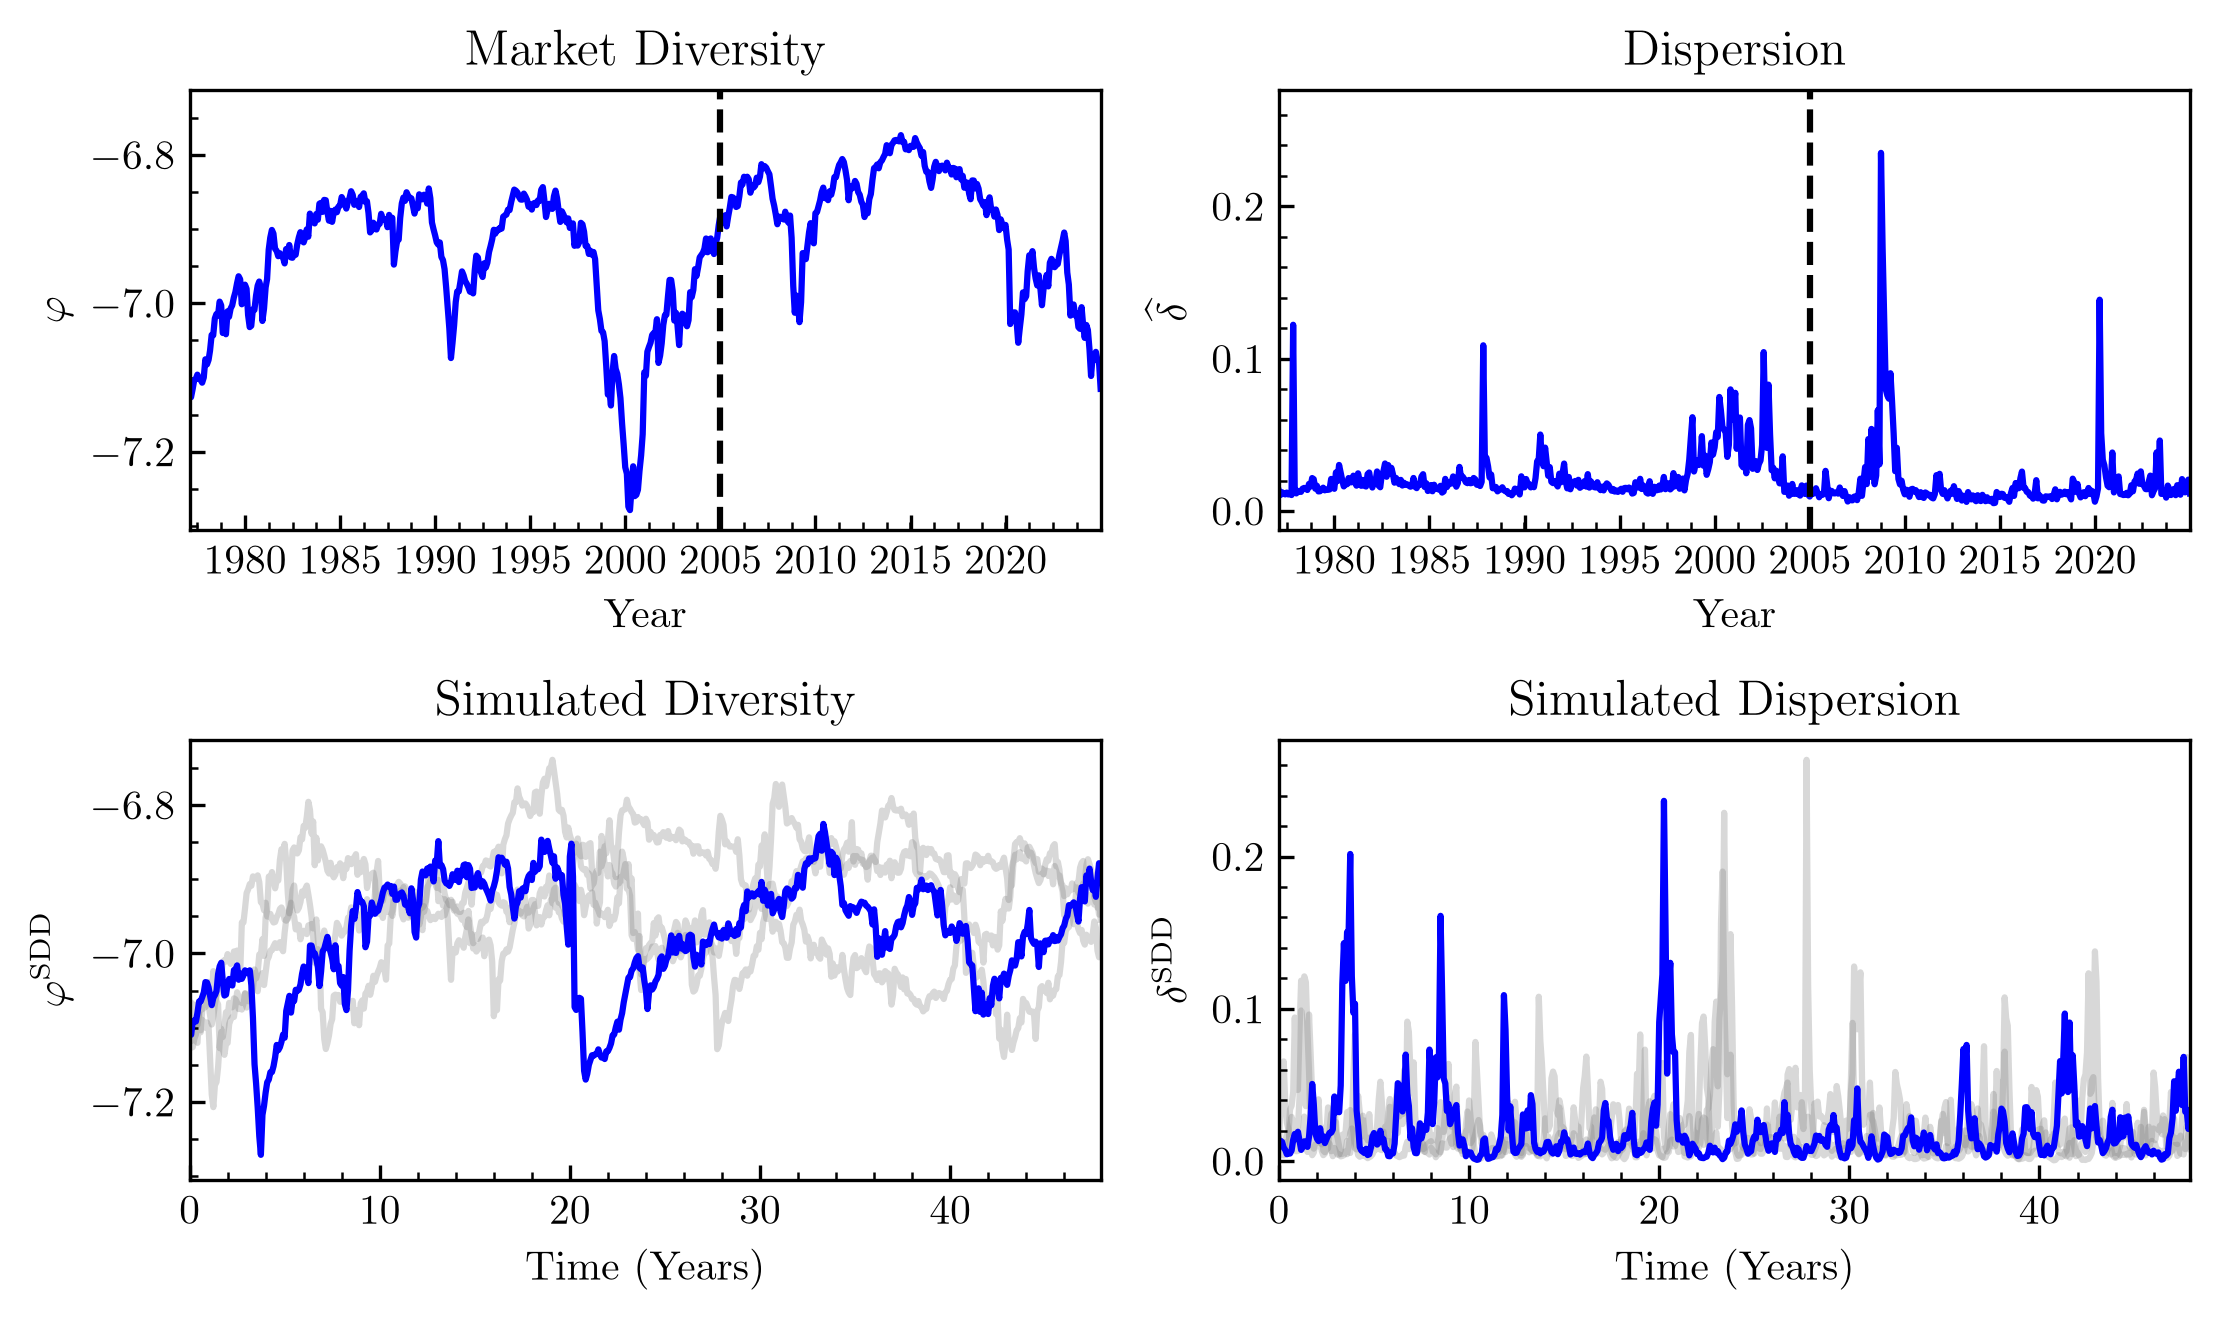

In [15]:
sim_phi, sim_delta = plotting.simulate_and_plot(
    sdd_model,
    diversity_monthly,
    dispersion_monthly,
    IS_end_date=IS_END_DATE,
    seed=SEED,
    save_fig=True,
    figsize=(1.5 * width, 1.5 * height),
    tight_layout=True,
    sharey="col",
)

## 3. Stylized facts

Saved figure to ./figures/sim_dists.pdf


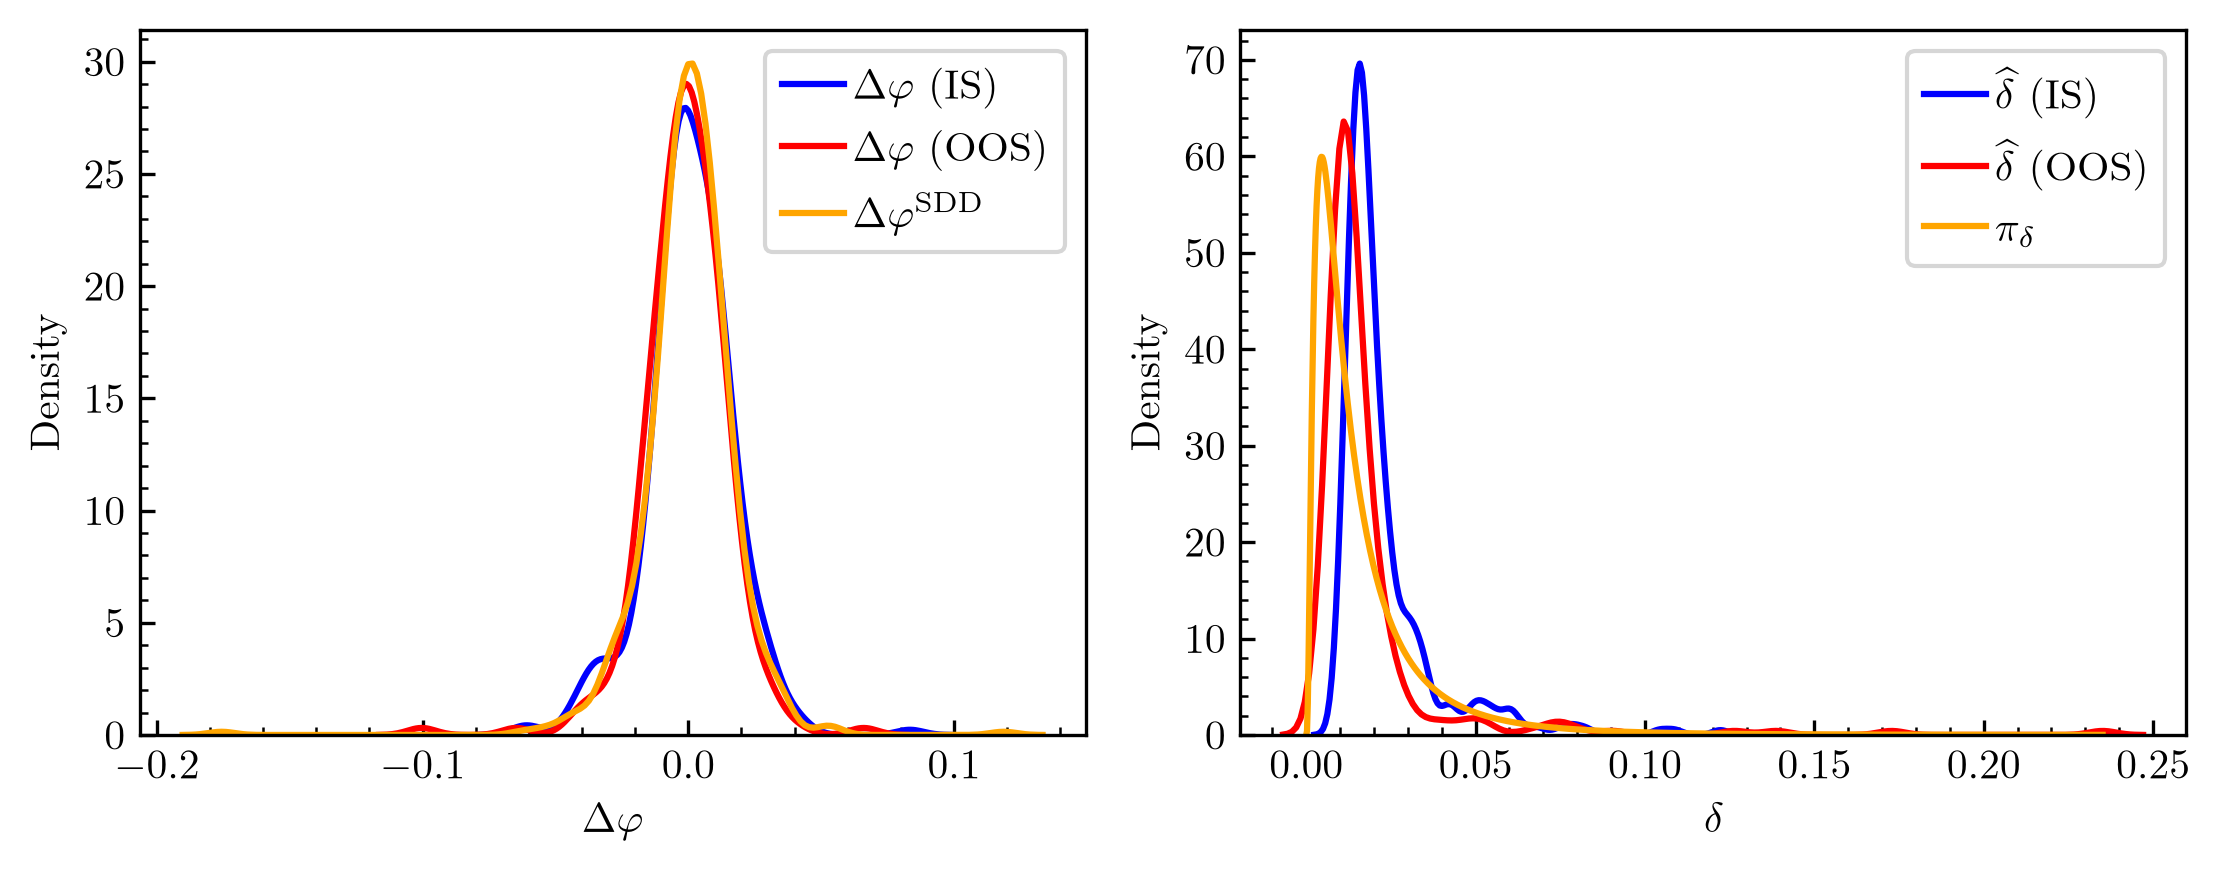

In [16]:
# plotting simulated distributions against in-sample and out-of-sample data
plotting.plot_sim_dists(
    sim_phi=sim_phi,
    IS_data=IS_monthly_data,
    OOS_data=OOS_monthly_data,
    sdd_model=sdd_model,
    figsize=(1.5 * width, height),
    tight_layout=True,
)

In-sample fit:
Calibrated right-tail parameters:
mu=-4.1105, sigma=0.7102
Out-of-sample fit:
Calibrated right-tail parameters:
mu=-5.4520, sigma=1.4618
Saved figure to ./figures/sim_moments.pdf


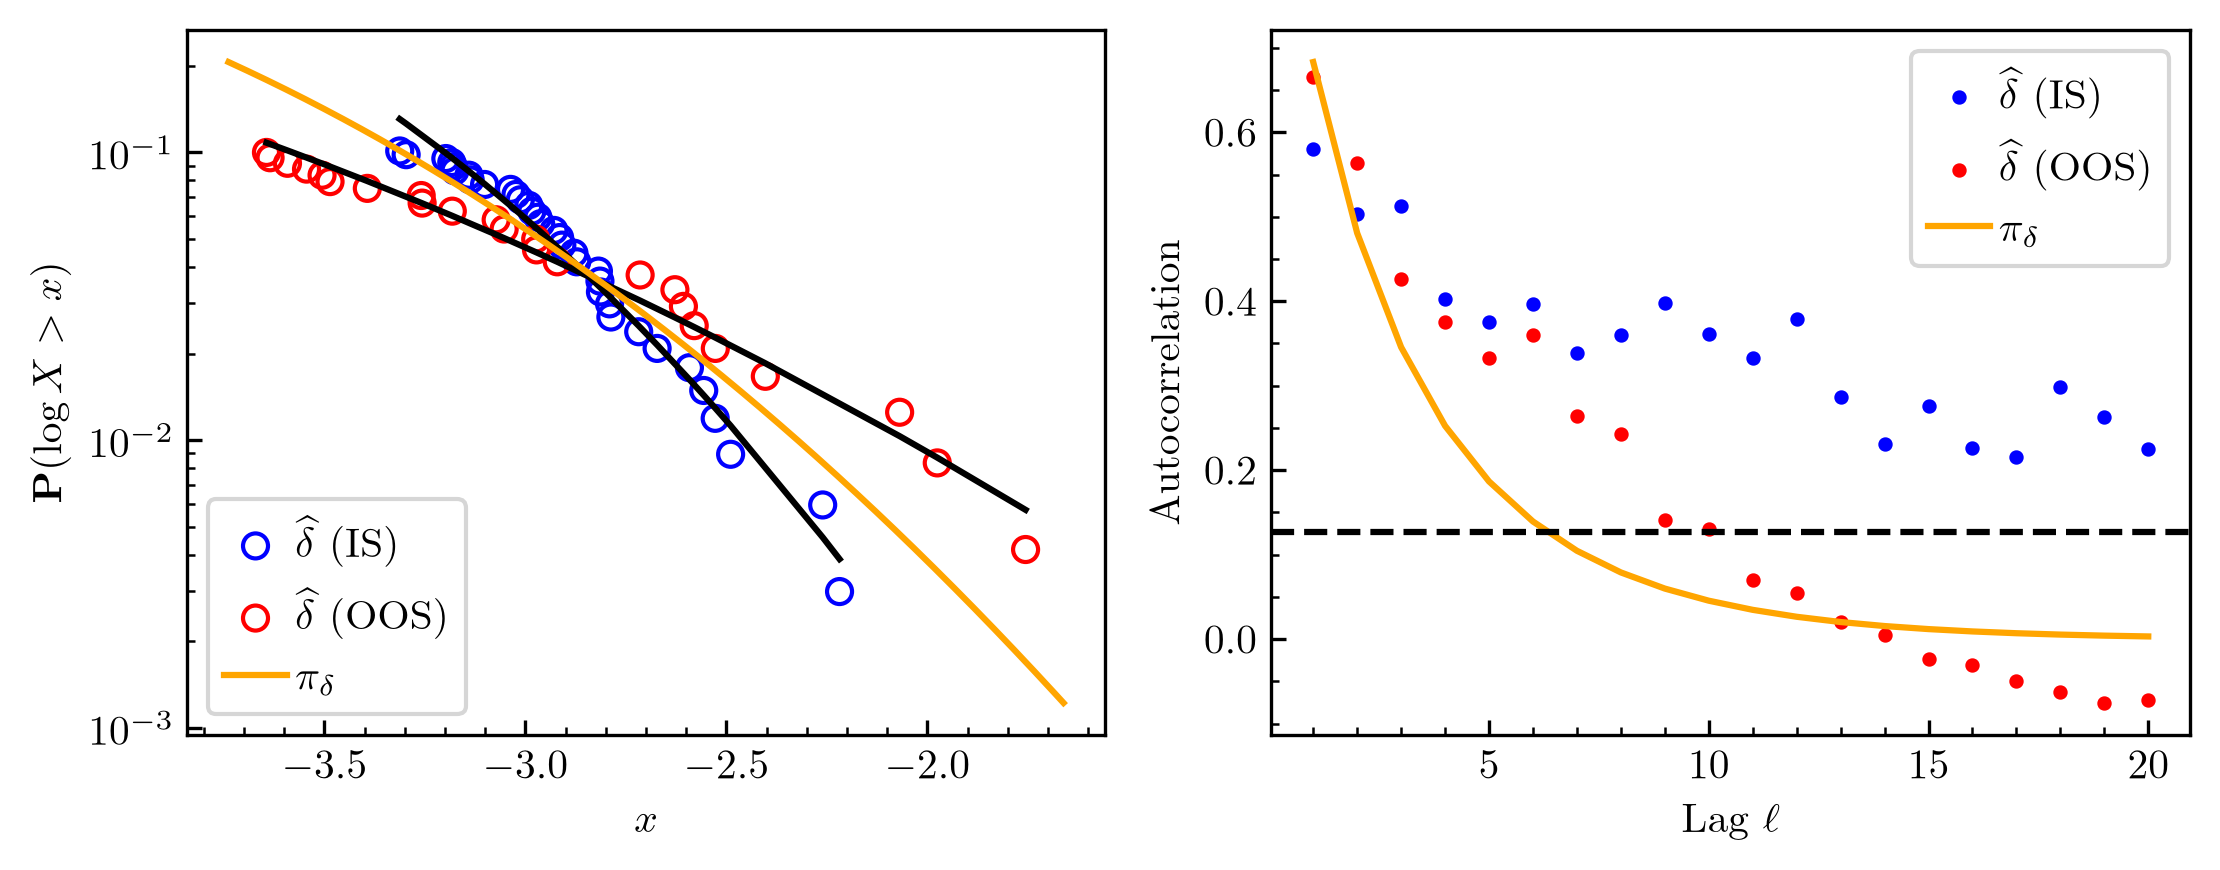

In [17]:
# plotting simulated moments of dispersion against in-sample and out-of-sample data
plotting.plot_sim_moments(
    sdd_model=sdd_model,
    IS_monthly_data=IS_monthly_data,
    OOS_monthly_data=OOS_monthly_data,
    figsize=(1.5 * width, height),
    tight_layout=True,
)

Saved figure to ./figures/sim_lowess.pdf


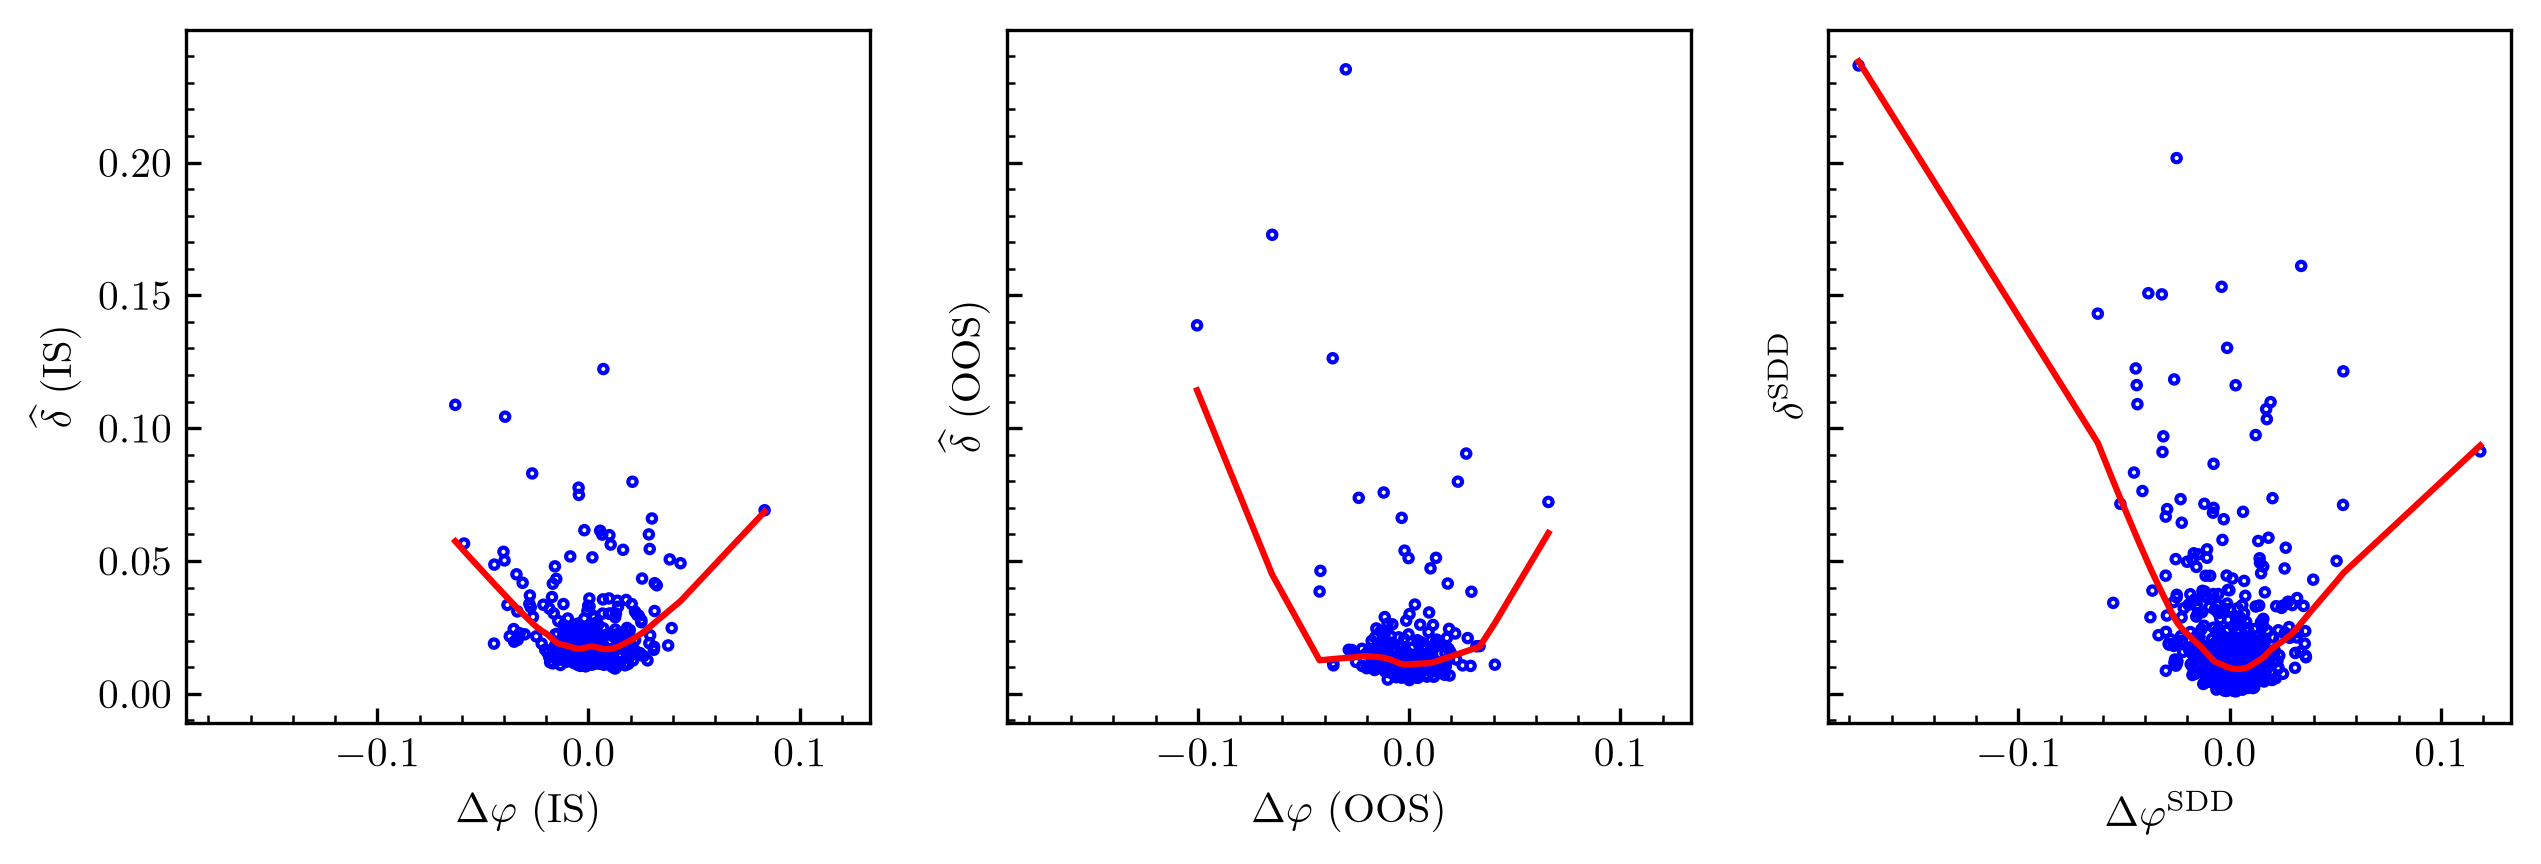

In [18]:
# plotting changes in diversity against dispersion in-sample and out-of-sample vs simulation
plotting.plot_sim_lowess(
    sim_phi=sim_phi,
    sim_delta=sim_delta,
    IS_monthly_data=IS_monthly_data,
    OOS_monthly_data=OOS_monthly_data,
    frac=0.4,
    figsize=(2 * width, height),
    sharex=True,
    sharey=True,
)